# 1.线性回归

*回归*（regression）是能为一个或多个自变量与因变量之间关系建模的一类方法。
在自然科学和社会科学领域，回归经常用来表示输入和输出之间的关系。

在机器学习领域中的大多数任务通常都与*预测*（prediction）有关。
当我们想预测一个数值时，就会涉及到回归问题。
常见的例子包括：预测价格（房屋、股票等）、预测住院时间（针对住院病人等）、
预测需求（零售销量等）。
但不是所有的*预测*都是回归问题。
在后面的章节中，我们将介绍分类问题。分类问题的目标是预测数据属于一组类别中的哪一个。

## 1.1线性回归的基本元素

*线性回归*（linear regression）可以追溯到19世纪初，
它在回归的各种标准工具中最简单而且最流行。
线性回归基于几个简单的假设：
首先，假设自变量$\mathbf{x}$和因变量$y$之间的关系是线性的，
即$y$可以表示为$\mathbf{x}$中元素的加权和，这里通常允许包含观测值的一些噪声；
其次，我们假设任何噪声都比较正常，如噪声遵循正态分布。

为了解释*线性回归*，我们举一个实际的例子：
我们希望根据房屋的面积（平方英尺）和房龄（年）来估算房屋价格（美元）。
为了开发一个能预测房价的模型，我们需要收集一个真实的数据集。
这个数据集包括了房屋的销售价格、面积和房龄。
在机器学习的术语中，该数据集称为*训练数据集*（training data set）
或*训练集*（training set）。
每行数据（比如一次房屋交易相对应的数据）称为*样本*（sample），
也可以称为*数据点*（data point）或*数据样本*（data instance）。
我们把试图预测的目标（比如预测房屋价格）称为*标签*（label）或*目标*（target）。
**预测所依据的自变量（面积和房龄）称为*特征*（feature）或*协变量***（covariate）。

通常，我们使用$n$来表示数据集中的样本数。
对索引为$i$的样本，其输入表示为$\mathbf{x}^{(i)} = [x_1^{(i)}, x_2^{(i)}]^\top$，
其对应的标签是$y^{(i)}$。

### 1.1.1线性模型

线性假设是指目标（房屋价格）可以表示为特征（面积和房龄）的加权和，如下面的式子：

$$\mathrm{price} = w_{\mathrm{area}} \cdot \mathrm{area} + w_{\mathrm{age}} \cdot \mathrm{age} + b.$$


中的$w_{\mathrm{area}}$和$w_{\mathrm{age}}$
称为*权重*（weight），权重决定了每个特征对我们预测值的影响。
$b$称为*偏置*（bias）、*偏移量*（offset）或*截距*（intercept）。
偏置是指当所有特征都取值为0时，预测值应该为多少。
即使现实中不会有任何房子的面积是0或房龄正好是0年，我们仍然需要偏置项。
如果没有偏置项，我们模型的表达能力将受到限制。
严格来说， 是输入特征的一个
*仿射变换*（affine transformation）。
仿射变换的特点是通过加权和对特征进行*线性变换*（linear transformation），
并通过偏置项来进行*平移*（translation）。

给定一个数据集，我们的目标是寻找模型的权重$\mathbf{w}$和偏置$b$，
使得根据模型做出的预测大体符合数据里的真实价格。
输出的预测值由输入特征通过*线性模型*的仿射变换决定，仿射变换由所选权重和偏置确定。

而在机器学习领域，我们通常使用的是高维数据集，建模时采用线性代数表示法会比较方便。
当我们的输入包含$d$个特征时，我们将预测结果$\hat{y}$
（通常使用“尖角”符号表示$y$的估计值）表示为：

$$\hat{y} = w_1  x_1 + ... + w_d  x_d + b.$$

将所有特征放到向量$\mathbf{x} \in \mathbb{R}^d$中，
并将所有权重放到向量$\mathbf{w} \in \mathbb{R}^d$中，
我们可以用点积形式来简洁地表达模型：

$$\hat{y} = \mathbf{w}^\top \mathbf{x} + b.$$


向量$\mathbf{x}$对应于单个数据样本的特征。
用符号表示的矩阵$\mathbf{X} \in \mathbb{R}^{n \times d}$
可以很方便地引用我们整个数据集的$n$个样本。
其中，$\mathbf{X}$的每一行是一个样本，每一列是一种特征。

对于特征集合$\mathbf{X}$，预测值$\hat{\mathbf{y}} \in \mathbb{R}^n$
可以通过矩阵-向量乘法表示为：

$${\hat{\mathbf{y}}} = \mathbf{X} \mathbf{w} + b$$

这个过程中的求和将使用广播机制
给定训练数据特征$\mathbf{X}$和对应的已知标签$\mathbf{y}$，
线性回归的目标是找到一组权重向量$\mathbf{w}$和偏置$b$：
当给定从$\mathbf{X}$的同分布中取样的新样本特征时，
这组权重向量和偏置能够使得新样本预测标签的误差尽可能小。

虽然我们相信给定$\mathbf{x}$预测$y$的最佳模型会是线性的，
但我们很难找到一个有$n$个样本的真实数据集，其中对于所有的$1 \leq i \leq n$，$y^{(i)}$完全等于$\mathbf{w}^\top \mathbf{x}^{(i)}+b$。
无论我们使用什么手段来观察特征$\mathbf{X}$和标签$\mathbf{y}$，
都可能会出现少量的观测误差。
因此，即使确信特征与标签的潜在关系是线性的，
我们也会加入一个噪声项来考虑观测误差带来的影响。

在开始寻找最好的*模型参数*（model parameters）$\mathbf{w}$和$b$之前，
我们还需要两个东西：
（1）一种模型质量的度量方式；
（2）一种能够更新模型以提高模型预测质量的方法。

### 1.1.2损失函数

在我们开始考虑如何用模型*拟合*（fit）数据之前，我们需要确定一个拟合程度的度量。
*损失函数*（loss function）能够量化目标的*实际*值与*预测*值之间的差距。
**通常我们会选择非负数作为损失，且数值越小表示损失越小，完美预测时的损失为0。**
回归问题中最常用的损失函数是平方误差函数。
当样本$i$的预测值为$\hat{y}^{(i)}$，其相应的真实标签为$y^{(i)}$时，
平方误差可以定义为以下公式：

$$l^{(i)}(\mathbf{w}, b) = \frac{1}{2} \left(\hat{y}^{(i)} - y^{(i)}\right)^2.$$


常数$\frac{1}{2}$不会带来本质的差别，但这样在形式上稍微简单一些
（因为当我们对损失函数求导后常数系数为1）。
由于训练数据集并不受我们控制，所以经验误差只是关于模型参数的函数。
为了进一步说明，来看下面的例子。
我们为一维情况下的回归问题绘制图像，如 所示。

![用线性模型拟合数据。](img/fit-linreg.svg)


由于平方误差函数中的二次方项，
估计值$\hat{y}^{(i)}$和观测值$y^{(i)}$之间较大的差异将导致更大的损失。
为了度量模型在整个数据集上的质量，我们需计算在训练集$n$个样本上的损失均值（也等价于求和）。

$$L(\mathbf{w}, b) =\frac{1}{n}\sum_{i=1}^n l^{(i)}(\mathbf{w}, b) =\frac{1}{n} \sum_{i=1}^n \frac{1}{2}\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)^2.$$

在训练模型时，我们希望寻找一组参数（$\mathbf{w}^*, b^*$），
这组参数能最小化在所有训练样本上的总损失。如下式：

$$\mathbf{w}^*, b^* = \operatorname*{argmin}_{\mathbf{w}, b}\  L(\mathbf{w}, b).$$

### 1.1.3解析解

线性回归刚好是一个很简单的优化问题。
与我们将在本书中所讲到的其他大部分模型不同，线性回归的解可以用一个公式简单地表达出来，
这类解叫作解析解（analytical solution）。
首先，我们将偏置$b$合并到参数$\mathbf{w}$中，合并方法是在包含所有参数的矩阵中附加一列。
我们的预测问题是最小化$\|\mathbf{y} - \mathbf{X}\mathbf{w}\|^2$。
这在损失平面上只有一个临界点，这个临界点对应于整个区域的损失极小点。
将损失关于$\mathbf{w}$的导数设为0，得到解析解：

$$\mathbf{w}^* = (\mathbf X^\top \mathbf X)^{-1}\mathbf X^\top \mathbf{y}.$$

像线性回归这样的简单问题存在解析解，但并不是所有的问题都存在解析解。
解析解可以进行很好的数学分析，但解析解对问题的限制很严格，导致它无法广泛应用在深度学习里。

### 1.1.4随机梯度下降

#### 第一步：弄懂一个核心比喻 —— “蒙眼下山”

假设你被蒙上眼睛，扔在了一座高山上，你的任务是**走到谷底（让误差/损失函数降到最低）**。
*   **你脚踩的坡度** = **梯度（导数）**。
*   **坡度最陡向下的方向** = **负梯度方向**。
*   **你迈出的一步的步长** = **学习率 ($\eta$)**。
*   你走到了谷底 = 模型训练成功，找到了最好的参数 $\mathbf{w}$ 和 $b$。

#### 第二步：为什么要加“小批量”和“随机”？

*   **纯粹的梯度下降（太慢了）：**
    要想准确知道哪边是下坡，你需要把整座山的地形都摸索一遍（遍历整个数据集）。假设你的数据集有100万张图片，你每走一步，都要把100万张图片算一遍。**结果：方向极其准确，但几百年也走不到谷底。**
*   **小批量随机梯度下降（Minibatch SGD，工业界的绝对主力）：**
    你不再摸清整座山，而是**每次随机摸脚边的几块石头（随机抽取一小批样本，比如32张图片）**。根据这32张图片，估算出一个大致的下坡方向，然后马上迈出一步。
    **结果：虽然走得路线有点歪歪扭扭（因为是随机抽的，有误差），但你迈步的频率极高，综合下来，你会飞速地冲向谷底！**

---

#### 第三步：拆解那两个吓人的数学公式

文字里出现了两套公式，其实说的是一回事：**“新参数 = 老参数 - 步长 $\times$ 坡度”**。

##### 公式 1：万能通用公式
$$(\mathbf{w},b) \leftarrow (\mathbf{w},b) - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \partial_{(\mathbf{w},b)} l^{(i)}(\mathbf{w},b)$$
*   **$\leftarrow$**：意思是“更新为”。（把右边算出来的结果，赋值给左边）
*   **$\eta$**：学习率（你迈步的步子有多大）。
*   **$|\mathcal{B}|$**：批量大小（Batch Size，比如一次抽32个样本，那 $|\mathcal{B}|$ 就是32）。
*   **$\sum \partial l^{(i)}$**：把这32个样本的“坡度（梯度）”全部加起来。
*   **$\frac{1}{|\mathcal{B}|} \sum$**：加起来再除以32，这不就是求**平均坡度**嘛！

**大白话翻译**：`当前的权重 = 之前的权重 - 步子大小 × 这批抽样算出来的平均下坡方向`。

##### 公式 2：线性回归的专属公式（最长的那一坨）
文字里特意把平方损失函数的求导结果写出来了。我们重点看 $\mathbf{w}$ 的更新：
$$ \mathbf{w} \leftarrow \mathbf{w} - \frac{\eta}{|\mathcal{B}|} \sum_{i \in \mathcal{B}} \mathbf{x}^{(i)} \left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right) $$
看着头晕？我们把它大卸八块，结合你刚学的链式法则：
1.  **预测值**是： $\hat{y}^{(i)} = \mathbf{w}^\top \mathbf{x}^{(i)} + b$
2.  **预测误差**是： $(\text{预测值} - \text{真实值})$，也就是 $\left(\mathbf{w}^\top \mathbf{x}^{(i)} + b - y^{(i)}\right)$。
3.  根据链式法则，损失函数对 $\mathbf{w}$ 求导，会多出来一个输入特征 $\mathbf{x}^{(i)}$。（就跟你上一节课问的 $y=x^2$ 求导多出个 $x$ 一样）。
4.  所以，括号里的那一坨，根本不是什么神秘的东西，**它就是： 输入数据 $\times$ 误差！**

**这个公式极其符合直觉：**
*   如果预测得很准（误差为0），括号里就是0，$\mathbf{w}$ 就不更新了（走到谷底了）。
*   如果误差很大，$\mathbf{w}$ 就会根据误差的大小和输入数据的方向，狠狠地更新一次。

---

#### 第四步：理清两个核心概念

这段文字最后讲了两个日常“炼丹”（训练模型）必备的常识：

##### 1. 参数 (Parameter) vs 超参数 (Hyperparameter)
*   **参数 ($\mathbf{w}, b$)**：**机器自己学出来的东西**。你不管，让电脑自己通过梯度下降去更新。
*   **超参数 ($\eta$ 学习率, $|\mathcal{B}|$ 批量大小)**：**需要你（人类）手动设定的东西**。设定这些参数的过程，就叫“调参”。（比如你发现模型怎么都不收敛，可能就是你步子迈太大了（$\eta$ 太大），直接跨过了谷底）。

##### 2. 什么是“泛化 (Generalization)”？（深度学习的终极灵魂）
如果你在训练时，疯狂地更新参数，让模型在**训练集**上的误差降到了绝对的0。这件好事吗？
**绝不是！这叫“死记硬背”（过拟合）。**
就像一个学生把历年真题的答案一字不差全背下来了（训练集得满分），但一上考场遇到没见过的新题，直接得0分。

**文字最后一句话的意思是：** 我们训练模型的根本目的，不是为了在已经见过的数据（训练集）上考满分，而是为了让模型拥有举一反三的能力，**在从来没见过的新数据上表现优秀**。这种能力，就叫**泛化**。

---

**要记住这三个点，就彻底学透了：**
1. **SGD 是什么**：每次随机抓一小把数据算均值梯度，既快又能保证方向大致正确。
2. **怎么更新的**：新参数 = 老参数 - (学习率 × 误差梯度)。
3. **人类的任务**：人类负责调**超参数**（步长、批量），机器负责调**参数**（权重），最终目的是在没见过的数据上表现好（泛化），而不是在训练集上死记硬背。


### 1.1.5用模型进行预测

给定“已学习”的线性回归模型$\hat{\mathbf{w}}^\top \mathbf{x} + \hat{b}$，
现在我们可以通过房屋面积$x_1$和房龄$x_2$来估计一个（未包含在训练数据中的）新房屋价格。
给定特征估计目标的过程通常称为*预测*（prediction）或*推断*（inference）。

本书将尝试坚持使用*预测*这个词。
虽然*推断*这个词已经成为深度学习的标准术语，但其实*推断*这个词有些用词不当。
在统计学中，*推断*更多地表示基于数据集估计参数。
当深度学习从业者与统计学家交谈时，术语的误用经常导致一些误解。

## 2.矢量化加速

在训练我们的模型时，我们经常希望能够同时处理整个小批量的样本。
为了实现这一点，需要(**我们对计算进行矢量化，
从而利用线性代数库，而不是在Python中编写开销高昂的for循环**)。



In [1]:
%matplotlib inline
import math
import time
import numpy as np
import torch
from d2l import torch as d2l

为了说明矢量化为什么如此重要，我们考虑(**对向量相加的两种方法**)。
我们实例化两个全为1的10000维向量。
在一种方法中，我们将使用Python的for循环遍历向量；
在另一种方法中，我们将依赖对`+`的调用。


In [11]:
n =10000
a = torch.ones([n])#一维张量（此处是使用列表进行创建的。列表可以升级到高纬的情况）
b = torch.ones([n])
a,b,a.shape, b.shape

(tensor([1., 1., 1.,  ..., 1., 1., 1.]),
 tensor([1., 1., 1.,  ..., 1., 1., 1.]),
 torch.Size([10000]),
 torch.Size([10000]))

由于在本书中我们将频繁地进行运行时间的基准测试，所以[**我们定义一个计时器**]：


In [ ]:
class Timer:  #定义一个名为Timer的类
    """记录多次运行时间"""
    def __init__(self):#类的构造函数，当创建Timer实例时自动调用
        self.times = []#创建一个空列表，用于存储每次计时的时间
        self.start()#开始计时

    def start(self):
        """启动计时器"""
        self.tik = time.time()

    def stop(self):
        """停止计时器并将时间记录在列表中"""
        self.times.append(time.time() - self.tik)
        return self.times[-1]

    def avg(self):
        """返回平均时间"""
        return sum(self.times) / len(self.times)

    def sum(self):
        """返回时间总和"""
        return sum(self.times)

    def cumsum(self):
        """返回累计时间"""
        return np.array(self.times).cumsum().tolist()

现在我们可以对工作负载进行基准测试。

首先，[**我们使用for循环，每次执行一位的加法**]。


In [14]:
c = torch.zeros([n])#创建一个Timer类的实例，会自动调用__init__方法，初始化时间列表并启动计时器
timer = Timer()
for i in range(n):
    c[i] = a[i] + b[i]
f'{timer.stop():.5f} sec'

'0.06457 sec'

(**或者，我们使用重载的`+`运算符来计算按元素的和**)。

矢量化代码加速的含义：
矢量化代码加速是指利用向量化操作替代循环操作，从而显著提高代码执行速度。让我从几个方面解释这个概念：

1. 向量化操作的本质
在PyTorch中，向量化操作是指对整个张量进行一次性操作，而不是逐个元素处理。例如：
```python
# 非矢量化方式（慢）
for i in range(n):
    c[i] = a[i] + b[i]

# 矢量化方式（快）
c = a + b
```

In [16]:
timer.start()
d = a + b
f'{timer.stop():.5f} sec'

'0.00000 sec'

结果很明显，第二种方法比第一种方法快得多。
矢量化代码通常会带来数量级的加速。
另外，我们将更多的数学运算放到库中，而无须自己编写那么多的计算，从而减少了出错的可能性。

## 3.正态分布与平方损失

接下来，我们通过对噪声分布的假设来解读平方损失目标函数。

正态分布和线性回归之间的关系很密切。
正态分布（normal distribution），也称为*高斯分布*（Gaussian distribution），
最早由德国数学家高斯（Gauss）应用于天文学研究。
简单的说，若随机变量$x$具有均值$\mu$和方差$\sigma^2$（标准差$\sigma$），其正态分布概率密度函数如下：

$$p(x) = \frac{1}{\sqrt{2 \pi \sigma^2}} \exp\left(-\frac{1}{2 \sigma^2} (x - \mu)^2\right).$$

下面[**我们定义一个Python函数来计算正态分布**]。


In [18]:
def normal(x, mu, sigma):
    p = 1 / math.sqrt(2 * math.pi * sigma**2)
    return p * np.exp(-0.5 / sigma**2 * (x - mu)**2)

我们现在(**可视化正态分布**)。


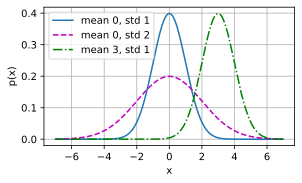

In [20]:
# 再次使用numpy进行可视化
x = np.arange(-7, 7, 0.01)

# 均值和标准差对
params = [(0, 1), (0, 2), (3, 1)]
d2l.plot(x, [normal(x, mu, sigma) for mu, sigma in params], xlabel='x',
        ylabel='p(x)', figsize=(4.5, 2.5),
        legend=[f'mean {mu}, std {sigma}' for mu, sigma in params])

## 4.从线性回归到深度网络

到目前为止，我们只谈论了线性模型。
尽管神经网络涵盖了更多更为丰富的模型，我们依然可以用描述神经网络的方式来描述线性模型，
从而把线性模型看作一个神经网络。
首先，我们用“层”符号来重写这个模型。

### 4.1神经网络图

深度学习从业者喜欢绘制图表来可视化模型中正在发生的事情。
我们将线性回归模型描述为一个神经网络。
需要注意的是，该图只显示连接模式，即只显示每个输入如何连接到输出，隐去了权重和偏置的值。

![线性回归是一个单层神经网络。](img/singleneuron.svg)


所示的神经网络中，输入为$x_1, \ldots, x_d$，
因此输入层中的*输入数*（或称为*特征维度*，feature dimensionality）为$d$。
网络的输出为$o_1$，因此输出层中的*输出数*是1。
需要注意的是，输入值都是已经给定的，并且只有一个*计算*神经元。
由于模型重点在发生计算的地方，所以通常我们在计算层数时不考虑输入层。
也就是说， 中神经网络的*层数*为1。
我们可以将线性回归模型视为仅由单个人工神经元组成的神经网络，或称为单层神经网络。

对于线性回归，每个输入都与每个输出（在本例中只有一个输出）相连，
我们将这种变换（中的输出层）
称为*全连接层*（fully-connected layer）或称为*稠密层*（dense layer）。
下一章将详细讨论由这些层组成的网络。

### 4.2生物学

线性回归发明的时间（1795年）早于计算神经科学，所以将线性回归描述为神经网络似乎不合适。
当控制学家、神经生物学家沃伦·麦库洛奇和沃尔特·皮茨开始开发人工神经元模型时，
他们为什么将线性模型作为一个起点呢？
我们来看一张图片
这是一张由*树突*（dendrites，输入终端）、
*细胞核*（nucleus，CPU）组成的生物神经元图片。
*轴突*（axon，输出线）和*轴突端子*（axon terminal，输出端子）
通过*突触*（synapse）与其他神经元连接。

![真实的神经元。](img/neuron.svg)


树突中接收到来自其他神经元（或视网膜等环境传感器）的信息$x_i$。
该信息通过*突触权重*$w_i$来加权，以确定输入的影响（即，通过$x_i w_i$相乘来激活或抑制）。
来自多个源的加权输入以加权和$y = \sum_i x_i w_i + b$的形式汇聚在细胞核中，
然后将这些信息发送到轴突$y$中进一步处理，通常会通过$\sigma(y)$进行一些非线性处理。
之后，它要么到达目的地（例如肌肉），要么通过树突进入另一个神经元。

当然，许多这样的单元可以通过正确连接和正确的学习算法拼凑在一起，
从而产生的行为会比单独一个神经元所产生的行为更有趣、更复杂，
这种想法归功于我们对真实生物神经系统的研究。

当今大多数深度学习的研究几乎没有直接从神经科学中获得灵感。
我们援引斯图尔特·罗素和彼得·诺维格在他们的经典人工智能教科书
*Artificial Intelligence:A Modern Approach* 
中所说的：虽然飞机可能受到鸟类的启发，但几个世纪以来，鸟类学并不是航空创新的主要驱动力。
同样地，如今在深度学习中的灵感同样或更多地来自数学、统计学和计算机科学。

## 5.练习
1. 假设我们有一些数据$x_1, \ldots, x_n \in \mathbb{R}$。我们的目标是找到一个常数$b$，使得最小化$\sum_i (x_i - b)^2$。
    1. 找到最优值$b$的解析解。
    1. 这个问题及其解与正态分布有什么关系?

In [ ]:
n = 1000
x = torch.randn(n,requires_grad=False)
b = torch.randn(1, requires_grad=True)
# y = (torch.sum((x - b) ** 2))
y = torch.mean((x - b) ** 2)  # 使用torch.mean更简洁 并且torch.mean = torch.sum()/n

y.backward()
b.grad

tensor([1.9410])

2. 推导出使用平方误差的线性回归优化问题的解析解。为了简化问题，可以忽略偏置$b$（我们可以通过向$\mathbf X$添加所有值为1的一列来做到这一点）。
    1. 用矩阵和向量表示法写出优化问题（将所有数据视为单个矩阵，将所有目标值视为单个向量）。
    1. 计算损失对$w$的梯度。
    1. 通过将梯度设为0、求解矩阵方程来找到解析解。
    1. 什么时候可能比使用随机梯度下降更好？这种方法何时会失效？